In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import gymnasium as gym
import mountain


Load trajectories

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment mountain/GridWorld-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(
<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


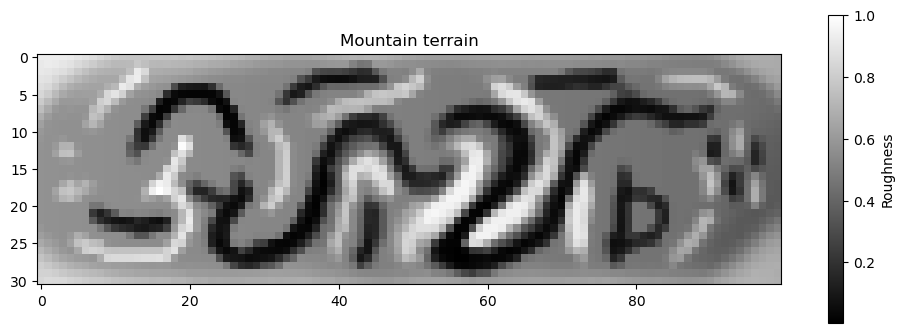

In [2]:
with open("trajectories.pickle", "rb") as f:
    trajectories = pickle.load(f)

ROWS, COLS = 31, 100


#The map
env = gym.make('mountain/GridWorld-v1')
terrain = env.unwrapped.MAP

plt.figure(figsize=(12,4))
plt.imshow(terrain, cmap="gray", origin="upper")
plt.colorbar(label="Roughness")
plt.title("Mountain terrain")
plt.show()

What task 5.1 is asking:

Use the recorded robot trajectories to estimate how good each state is under the unknown policy 𝜋 by averaging the total reward observed after visiting that state.

What the method returns:
The MC state-value function mc_eval_V returns a mapping from each state s to the estimated expected cumulative reward obtained when starting from s and following policy π.

Task 1:

MC evaluation for vπ(s)

In [3]:
def mc_eval_V(trajectories, gamma=1.0, first_visit=True):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    for episode in trajectories:
        # episode is a list of (s, a, r, s_next)
        states = [step[0] for step in episode]
        rewards = [float(step[2]) for step in episode]  # r_t

        # compute returns G_t backwards
        G = 0.0
        returns = [0.0] * len(rewards)
        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            returns[t] = G

        visited = set()
        for t, s in enumerate(states):
            if first_visit and s in visited:
                continue
            visited.add(s)
            returns_sum[s] += returns[t]
            returns_count[s] += 1

    V = {s: returns_sum[s] / returns_count[s] for s in returns_sum}
    return V

In [4]:
V = mc_eval_V(trajectories, gamma=1.0, first_visit=True)
print("Number of states estimated:", len(V))
print("V((15,0)):", V.get((15,0)))

Number of states estimated: 2924
V((15,0)): -78.13585565252045


Task 2:

What the question asks:

Use the same trajectories to estimate how good each state–action pair is under policy 𝜋 by averaging the total reward observed after taking action 𝑎 in state 𝑠.

What the method returns:

The MC action-value function mc_eval_Q returns a mapping from each state–action pair (s,a) to the estimated expected cumulative reward obtained when starting from s, taking action a, and then following policy π.

In [5]:
def mc_eval_Q(trajectories, gamma=1.0, first_visit=True):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    for episode in trajectories:
        states = [step[0] for step in episode]
        actions = [int(step[1]) for step in episode]
        rewards = [float(step[2]) for step in episode]

        G = 0.0
        returns = [0.0] * len(rewards)
        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            returns[t] = G

        visited = set()
        for t, (s, a) in enumerate(zip(states, actions)):
            key = (s, a)
            if first_visit and key in visited:
                continue
            visited.add(key)
            returns_sum[key] += returns[t]
            returns_count[key] += 1

    Q = {k: returns_sum[k] / returns_count[k] for k in returns_sum}
    return Q

In [6]:
Q = mc_eval_Q(trajectories, gamma=1.0, first_visit=True)
print("Number of (s,a) estimated:", len(Q))
print("Q((15,0),0):", Q.get(((15,0),0)))

Number of (s,a) estimated: 14138
Q((15,0),0): -77.43312773207876


In [7]:
V_grid = np.full((ROWS, COLS-1), np.nan)

for (i, j), v in V.items():
    V_grid[i, j] = v

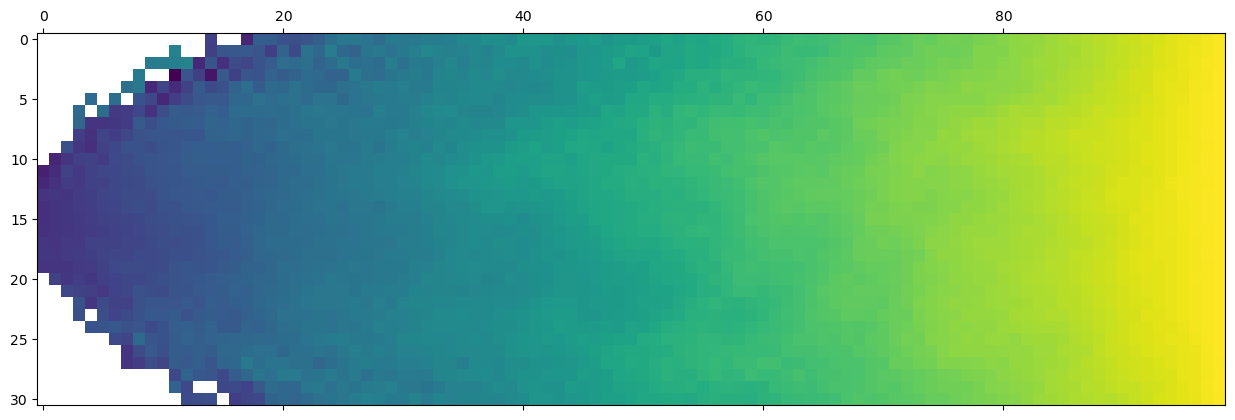

In [8]:
plt.matshow(V_grid)
# plt.figure(figsize=(12,4))
# plt.imshow(V_grid, cmap="viridis", origin="upper")
# plt.colorbar(label="vπ(s)")
# plt.title("Monte Carlo vπ(s) (only visited states)")
plt.show()

Task 4:

In [9]:
def mc_improve_policy_from_Q(Q, default_action=0):
    """
    Q: dict with keys ((i,j), a) -> q value
    returns: policy array (ROWS,COLS) with action indices
    """
    pi_new = np.full((ROWS, COLS), default_action, dtype=int)

    # group Q-values by state
    q_by_state = defaultdict(dict)
    for (s, a), q in Q.items():
        q_by_state[s][a] = q

    # choose best observed action in each visited state
    for s, qdict in q_by_state.items():
        best_a = max(qdict, key=qdict.get)
        pi_new[s] = best_a

    return pi_new

pi_new = mc_improve_policy_from_Q(Q, default_action=0)

measure how many states you actually improved:

In [10]:
visited_states = {s for (s,a) in Q.keys()}
print("States with at least one Q estimate:", len(visited_states), "out of", ROWS*COLS)

States with at least one Q estimate: 2924 out of 3100


Load the first version of the environment mountain (v1)

In [11]:
env1 = gym.make('mountain/GridWorld-v1')

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment mountain/GridWorld-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Task 7:

Choosing a starting policy -> Uniform random policy
- guarantees exploration
- unbiased (does not assume knowledge of terrain)
- ensures MC control can learn all state–action values


In [12]:
def obs_to_state(obs):
    r, c = obs["agent"]["pos"]
    return (int(r), int(c))

def epsilon_greedy(Q, s, eps):
    n_actions = Q.shape[-1]          # works for v1 and v2
    if np.random.rand() < eps:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[s[0], s[1], :]))

def mc_control(env, episodes=30000, gamma=1.0,
               eps_start=1.0, eps_end=0.1, eps_decay=0.9995):

    n_rows, n_cols = env.unwrapped.MAP.shape
    n_actions = env.action_space.n

    Q = np.zeros((n_rows, n_cols, n_actions), dtype=np.float64)
    N = np.zeros((n_rows, n_cols, n_actions), dtype=np.int32)

    eps = eps_start
    best_episode, best_return = None, -np.inf

    ep_returns = []  

    for ep in range(episodes):
        obs, _ = env.reset()
        episode = []

        done = False
        while not done:
            s = obs_to_state(obs)
            a = epsilon_greedy(Q, s, eps)
            obs2, r, terminated, truncated, _ = env.step(a)
            episode.append((s, a, float(r)))
            obs = obs2
            done = terminated or truncated

        G_total = sum(r for (_, _, r) in episode)
        ep_returns.append(G_total)  

        if G_total > best_return:
            best_return = G_total
            best_episode = episode

        # First-visit MC update
        G = 0.0
        seen = set()
        for (s, a, r) in reversed(episode):
            G = gamma * G + r
            if (s, a) in seen:
                continue
            seen.add((s, a))

            r0, c0 = s
            N[r0, c0, a] += 1
            Q[r0, c0, a] += (G - Q[r0, c0, a]) / N[r0, c0, a]

        eps = max(eps_end, eps * eps_decay)

    return Q, np.array(ep_returns)  

In [13]:
def plot_episode_on_map(env, episode, title="Trajectory"):
    mountain_map = env.unwrapped.MAP
    path_states = [s for (s, a, r) in episode]

    rows = [s[0] for s in path_states]
    cols = [s[1] for s in path_states]

    plt.figure(figsize=(16, 4))
    plt.imshow(mountain_map, aspect="auto", origin="upper")
    plt.plot(cols, rows, linewidth=2, c= "r")
    plt.scatter([cols[0]], [rows[0]], s=60, label="start")
    plt.scatter([cols[-1]], [rows[-1]], s=60, label="end")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.colorbar(label="Roughness / reward map values")
    plt.legend()
    plt.show()


In [14]:
def run_greedy_episode(env, Q, max_steps=2000):
    obs, info = env.reset()
    episode = []
    done = False
    steps = 0

    while not done and steps < max_steps:
        s = obs_to_state(obs)
        a = int(np.argmax(Q[s[0], s[1], :]))  # greedy action
        obs2, r, terminated, truncated, info2 = env.step(a)
        episode.append((s, a, float(r)))
        obs = obs2
        done = terminated or truncated
        steps += 1

    return episode, terminated, truncated, info2

In [15]:
Q_v1, mc_returns_v1 = mc_control(env1, episodes=10000)  

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


V1 greedy length: 125
V1 terminated: True truncated: False
V1 steps budget: 40.14102940305111 final pos: None


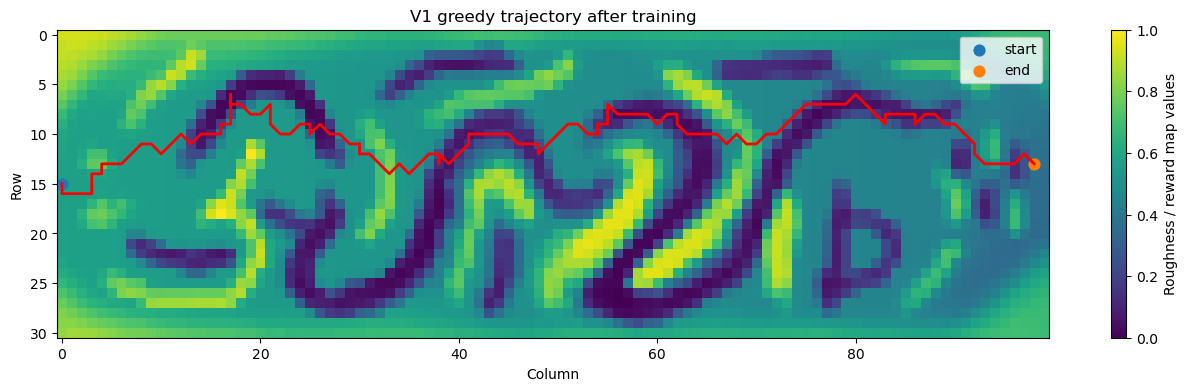

In [16]:
# v1
greedy_ep1, terminated1, truncated1, info_end1 = run_greedy_episode(env1, Q_v1)
print("V1 greedy length:", len(greedy_ep1))
print("V1 terminated:", terminated1, "truncated:", truncated1)
print("V1 steps budget:", info_end1.get("steps"), "final pos:", info_end1.get("pos"))
plot_episode_on_map(env1, greedy_ep1, title="V1 greedy trajectory after training")


#### MC control for v2:

In [17]:
env2 = gym.make('mountain/GridWorld-v2')

In [18]:
Q_v2, mc_returns_v2 = mc_control(env2, episodes=20000)  # v2 often needs more

V2 greedy length: 140
V2 terminated: True truncated: True
V2 steps budget: 80.08689924153539 final pos: None


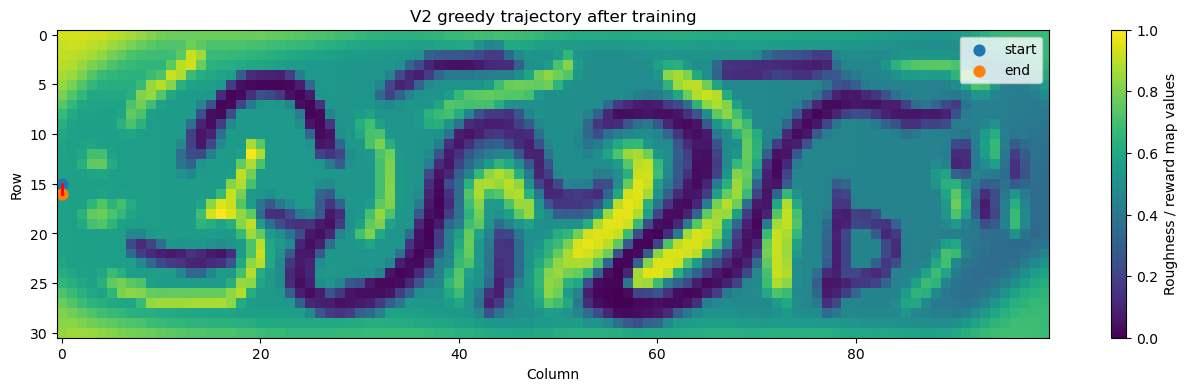

In [19]:
# v2
greedy_ep2, terminated2, truncated2, info_end2 = run_greedy_episode(env2, Q_v2)
print("V2 greedy length:", len(greedy_ep2))
print("V2 terminated:", terminated2, "truncated:", truncated2)
print("V2 steps budget:", info_end2.get("steps"), "final pos:", info_end2.get("pos"))
plot_episode_on_map(env2, greedy_ep2, title="V2 greedy trajectory after training")

Task: 11

SARSA is an on-policy TD control method. Instead of waiting for the episode to end (like MC), it updates online at every step using the TD target:

In [20]:
env = gym.make("mountain/GridWorld-v2")  # switch to v2 if needed
n_rows, n_cols = env.unwrapped.MAP.shape
n_actions = env.action_space.n

def obs_to_state(obs):
    r, c = obs["agent"]["pos"]
    return (int(r), int(c))

def epsilon_greedy(Q, s, eps):
    if np.random.rand() < eps:
        return np.random.randint(Q.shape[-1])
    return int(np.argmax(Q[s[0], s[1], :]))

def sarsa0(env, episodes=50000, alpha=0.1, gamma=1.0,
           eps_start=1.0, eps_end=0.05, eps_decay=0.9995):
    n_rows, n_cols = env.unwrapped.MAP.shape
    n_actions = env.action_space.n

    Q = np.zeros((n_rows, n_cols, n_actions), dtype=np.float64)
    eps = eps_start

    ep_returns = []

    for ep in range(episodes):
        obs, _ = env.reset()
        s = obs_to_state(obs)
        a = epsilon_greedy(Q, s, eps)

        done = False
        G_total = 0.0

        while not done:
            obs2, r, terminated, truncated, _ = env.step(a)
            s2 = obs_to_state(obs2)
            done = terminated or truncated
            G_total += float(r)

            if done:
                # terminal update (no next action value)
                td_target = float(r)
                td_error = td_target - Q[s[0], s[1], a]
                Q[s[0], s[1], a] += alpha * td_error
                break

            a2 = epsilon_greedy(Q, s2, eps)

            td_target = float(r) + gamma * Q[s2[0], s2[1], a2]
            td_error  = td_target - Q[s[0], s[1], a]
            Q[s[0], s[1], a] += alpha * td_error

            s, a = s2, a2

        ep_returns.append(G_total)
        eps = max(eps_end, eps * eps_decay)

    return Q, np.array(ep_returns)

In [21]:
def run_greedy_episode(env, Q, start_row=15, max_steps=5000):
    # Fix the start position in leftmost column (if env supports it)
    if hasattr(env.unwrapped, "set_start_position"):
        env.unwrapped.set_start_position((start_row, 0))

    obs, info = env.reset()  
    episode = []
    done = False
    steps = 0

    while not done and steps < max_steps:
        s = obs_to_state(obs)
        a = int(np.argmax(Q[s[0], s[1], :]))   # greedy
        obs2, r, terminated, truncated, info2 = env.step(a)
        episode.append((s, a, float(r)))
        obs = obs2
        done = terminated or truncated
        steps += 1

    return episode, terminated, truncated, info2

In [22]:
# --- Train with SARSA(0) ---
Q_sarsa, sarsa_returns_0 = sarsa0(env, episodes=20000, alpha=0.1, eps_decay=0.9995)

Greedy length: 1134 terminated: True truncated: True
steps budget: 80.03122829220058 final pos: None


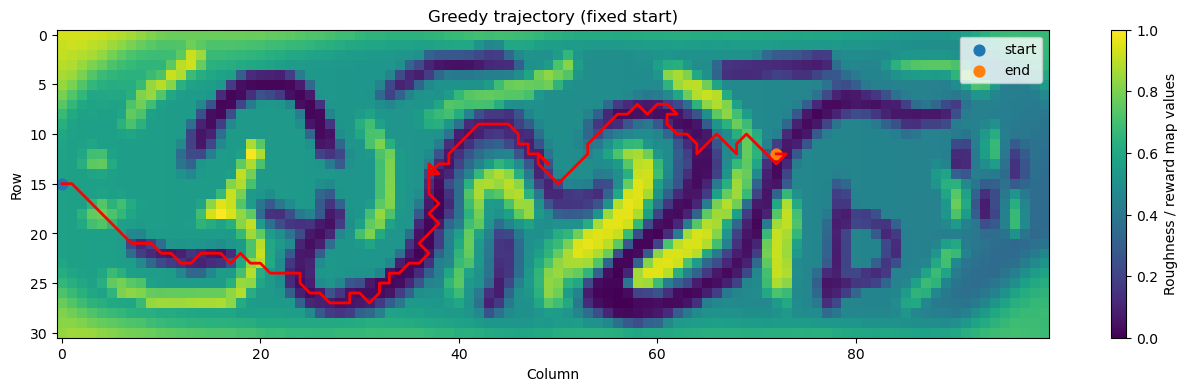

In [23]:
# --- Evaluate greedy policy ---
greedy_ep, terminated, truncated, info_end = run_greedy_episode(env, Q_sarsa, start_row=15)
print("Greedy length:", len(greedy_ep), "terminated:", terminated, "truncated:", truncated)
print("steps budget:", info_end.get("steps"), "final pos:", info_end.get("pos"))
plot_episode_on_map(env, greedy_ep, title="Greedy trajectory (fixed start)")

How the average training performance improves over time:

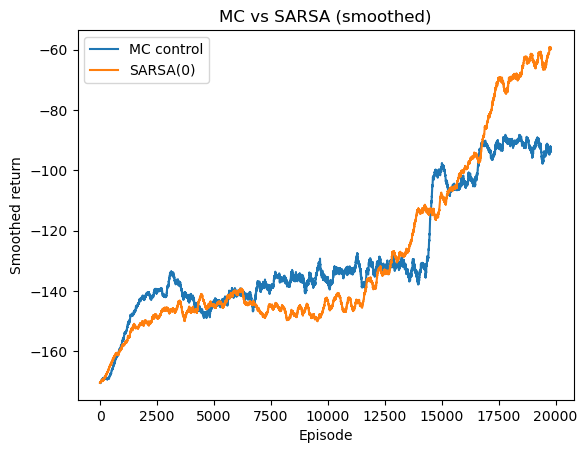

In [24]:
def moving_avg(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure()
plt.plot(moving_avg(mc_returns_v2), label="MC control")
plt.plot(moving_avg(sarsa_returns_0), label="SARSA(0)")
plt.xlabel("Episode")
plt.ylabel("Smoothed return")
plt.title("MC vs SARSA (smoothed)")
plt.legend()
plt.show()

Task 13:

In [25]:
def sarsa_n(env, n=3, episodes=50000, alpha=0.1, gamma=1.0,
            eps_start=1.0, eps_end=0.05, eps_decay=0.9995, max_steps=5000):

    n_rows, n_cols = env.unwrapped.MAP.shape
    n_actions = env.action_space.n

    Q = np.zeros((n_rows, n_cols, n_actions), dtype=np.float64)
    eps = eps_start
    ep_returns = []

    for ep in range(episodes):
        obs, _ = env.reset()
        s0 = obs_to_state(obs)
        a0 = epsilon_greedy(Q, s0, eps)

        states  = [s0]
        actions = [a0]
        rewards = [0.0]  # R_0 dummy so that rewards[t+1] is R_{t+1}

        T = np.inf
        t = 0
        G_total = 0.0

        while True:
            if t < T:
                obs2, r, terminated, truncated, _ = env.step(actions[t])
                r = float(r)
                G_total += r

                s_next = obs_to_state(obs2)
                states.append(s_next)
                rewards.append(r)

                if terminated or truncated or (t + 1) >= max_steps:
                    T = t + 1
                else:
                    a_next = epsilon_greedy(Q, s_next, eps)
                    actions.append(a_next)

            tau = t - n + 1
            if tau >= 0:
                # upper = min(tau+n, T) but without int(inf)
                upper = tau + n
                if T != np.inf:
                    upper = min(upper, T)

                # sum rewards from tau+1 to upper (inclusive)
                G = 0.0
                for i in range(tau + 1, int(upper) + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]

                # bootstrap if tau+n < T
                if (tau + n) < T:
                    s_boot = states[tau + n]
                    a_boot = actions[tau + n]
                    G += (gamma ** n) * Q[s_boot[0], s_boot[1], a_boot]

                s_tau = states[tau]
                a_tau = actions[tau]
                Q[s_tau[0], s_tau[1], a_tau] += alpha * (G - Q[s_tau[0], s_tau[1], a_tau])

            if tau == T - 1:
                break

            t += 1

        ep_returns.append(G_total)
        eps = max(eps_end, eps * eps_decay)

    return Q, np.array(ep_returns)

In [26]:
env = gym.make("mountain/GridWorld-v2")

ns = [1, 3, 5]
results = {}

for n in ns:
    Qn, returns_n = sarsa_n(env, n=n, episodes=20000, alpha=0.1,
                            eps_start=1.0, eps_end=0.05, eps_decay=0.9995)
    results[n] = (Qn, returns_n)
    print(f"Done n={n}, final mean return (last 100): {returns_n[-100:].mean():.2f}")

Done n=1, final mean return (last 100): -57.89
Done n=3, final mean return (last 100): -27.44
Done n=5, final mean return (last 100): -32.92


Task 13:

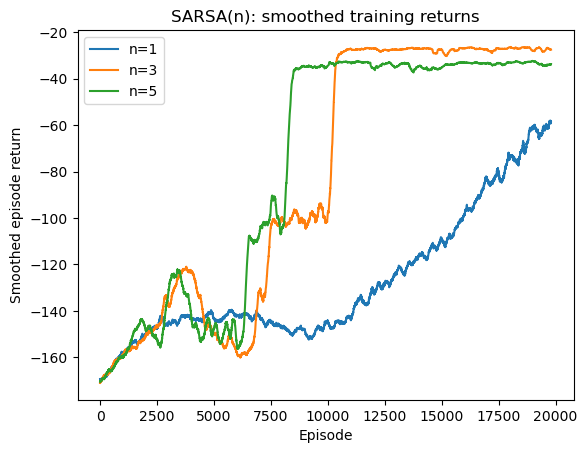

In [27]:
def moving_avg(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure()
for n in ns:
    plt.plot(moving_avg(results[n][1]), label=f"n={n}")
plt.title("SARSA(n): smoothed training returns")
plt.xlabel("Episode")
plt.ylabel("Smoothed episode return")
plt.legend()
plt.show()

Task 14:

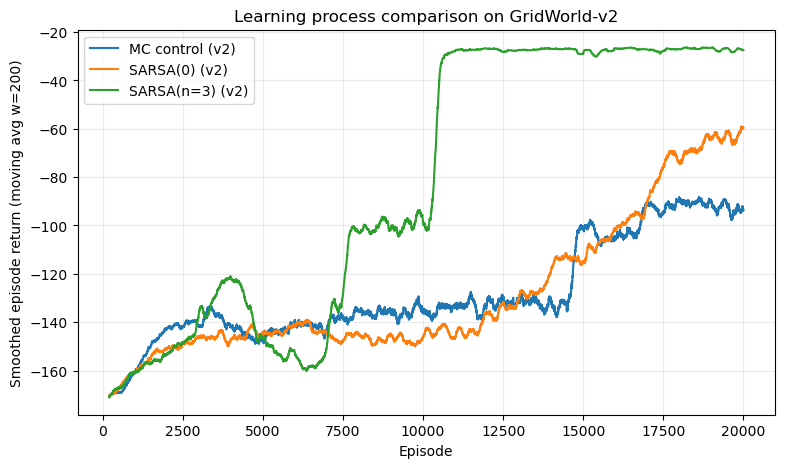

In [28]:
def moving_avg(x, w=200):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

# ---- SMOOTH ----
w = 200
mc_s = moving_avg(mc_returns_v2, w)
s0_s = moving_avg(sarsa_returns_0, w)
s3_s = moving_avg(results[3][1], w)

# x-axes (because moving average shortens the array)
x_mc = np.arange(len(mc_s)) + (w - 1)
x_s0 = np.arange(len(s0_s)) + (w - 1)
x_s3 = np.arange(len(s3_s)) + (w - 1)

# ---- PLOT ----
plt.figure(figsize=(9,5))
plt.plot(x_mc, mc_s, label="MC control (v2)")
plt.plot(x_s0, s0_s, label="SARSA(0) (v2)")
plt.plot(x_s3, s3_s, label="SARSA(n=3) (v2)")
plt.xlabel("Episode")
plt.ylabel(f"Smoothed episode return (moving avg w={w})")
plt.title("Learning process comparison on GridWorld-v2")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

In [29]:
def moving_avg(x, w=200):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

def plot_learning_curves(returns_dict, w=200, title="Learning process comparison", figsize=(9,5)):

    plt.figure(figsize=figsize)

    for label, returns in returns_dict.items():
        smoothed = moving_avg(returns, w)
        x = np.arange(len(smoothed)) + (w - 1)  # align with original episode index
        plt.plot(x, smoothed, label=label)

    plt.xlabel("Episode")
    plt.ylabel(f"Smoothed episode return (moving avg w={w})")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

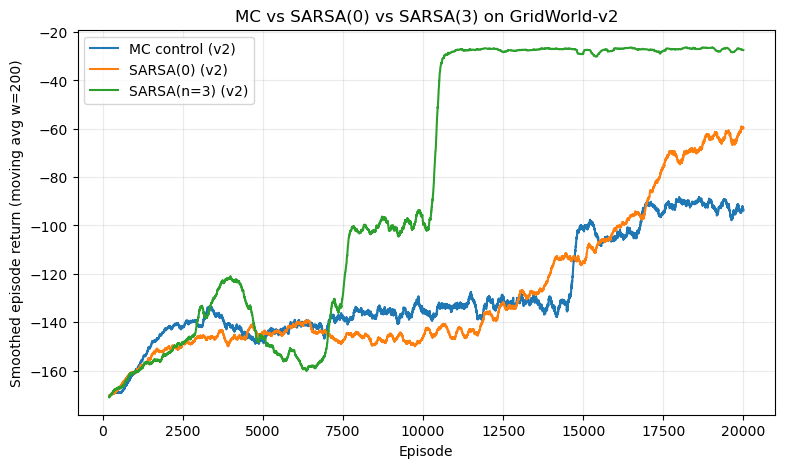

In [30]:
plot_learning_curves(
    {
        "MC control (v2)": mc_returns_v2,
        "SARSA(0) (v2)": sarsa_returns_0,
        "SARSA(n=3) (v2)": results[3][1],
    },
    w=200,
    title="MC vs SARSA(0) vs SARSA(3) on GridWorld-v2"
)

In [31]:
def obs_to_state(obs):
    r, c = obs["agent"]["pos"]
    return (int(r), int(c))

def epsilon_greedy(Q, s, eps):
    if np.random.rand() < eps:
        return np.random.randint(Q.shape[-1])
    return int(np.argmax(Q[s[0], s[1], :]))

def q_learning(env, episodes=50000, alpha=0.1, gamma=1.0,
               eps_start=1.0, eps_end=0.05, eps_decay=0.9995, max_steps=5000):
    n_rows, n_cols = env.unwrapped.MAP.shape
    n_actions = env.action_space.n

    Q = np.zeros((n_rows, n_cols, n_actions), dtype=np.float64)
    eps = eps_start
    ep_returns = []

    for ep in range(episodes):
        obs, _ = env.reset()
        done = False
        G_total = 0.0
        steps = 0

        while not done and steps < max_steps:
            s = obs_to_state(obs)
            a = epsilon_greedy(Q, s, eps)

            obs2, r, terminated, truncated, _ = env.step(a)
            s2 = obs_to_state(obs2)

            done = terminated or truncated
            r = float(r)
            G_total += r

            # Q-learning target: r + gamma * max_a' Q(s',a')
            if done:
                td_target = r
            else:
                td_target = r + gamma * np.max(Q[s2[0], s2[1], :])

            Q[s[0], s[1], a] += alpha * (td_target - Q[s[0], s[1], a])

            obs = obs2
            steps += 1

        ep_returns.append(G_total)
        eps = max(eps_end, eps * eps_decay)

    return Q, np.array(ep_returns)

In [32]:
Q_ql, ql_returns = q_learning(env, episodes=20000, alpha=0.1)

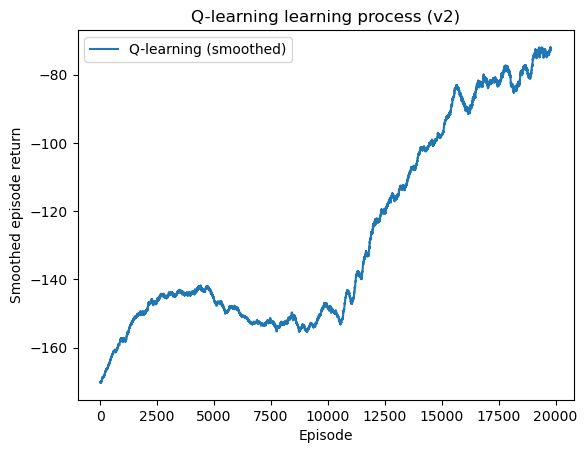

In [33]:
def moving_avg(x, w=200):
    x = np.asarray(x)
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure()
plt.plot(moving_avg(ql_returns), label="Q-learning (smoothed)")
plt.xlabel("Episode")
plt.ylabel("Smoothed episode return")
plt.title("Q-learning learning process (v2)")
plt.legend()
plt.show()

task 16:

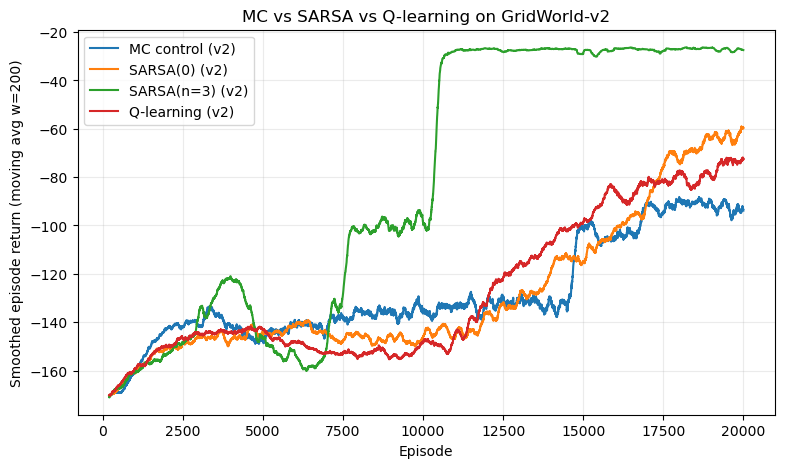

In [34]:
plot_learning_curves(
    {
        "MC control (v2)": mc_returns_v2,
        "SARSA(0) (v2)": sarsa_returns_0,
        "SARSA(n=3) (v2)": results[3][1],
        "Q-learning (v2)": ql_returns,
    },
    w=200,
    title="MC vs SARSA vs Q-learning on GridWorld-v2"
)